In [38]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mediapipe.python.solutions.hands as mp_hands

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import joblib

In [39]:
dataset_path = "dataset"

In [40]:
import os

dataset_path = "dataset"

print(os.path.exists(dataset_path))
print(len(os.listdir(dataset_path)))

True
36


In [41]:
classes = []

for item in os.listdir(dataset_path):

    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):
        classes.append(item)

classes = sorted(classes)

print(len(classes))
print(classes)

36
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


MEDIAPIPE HAND DETECTION :

In [42]:
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

data = []
labels = []

In [43]:
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

data = []
labels = []

for label in classes:

    folder = os.path.join(dataset_path, label)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        img = cv2.imread(image_path)

        if img is None:
            continue

        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = hands.process(rgb)

        if results.multi_hand_landmarks:

            hand = results.multi_hand_landmarks[0]

            #FEATURE EXTRACTION
            x_list = []
            y_list = []

            for lm in hand.landmark:
                x_list.append(lm.x)
                y_list.append(lm.y)

            #TRANSLATION NORMALIZATION
            min_x = min(x_list)
            min_y = min(y_list)

            #SCALE NORMALIZATION
            max_x = max(x_list)
            max_y = max(y_list)

            width = max_x - min_x
            height = max_y - min_y

            if width == 0 or height == 0:
                continue

            features = []

            for lm in hand.landmark:

                x = (lm.x - min_x) / width
                y = (lm.y - min_y) / height
                
                #FEATURE ENGINEERING
                features.append(x)
                features.append(y)

            data.append(features)
            labels.append(str(label))

In [44]:
print(len(data))
print(len(labels))

2641
2641


In [45]:
import pandas as pd

df = pd.DataFrame(data)

df["label"] = labels

print(df.shape)

df.head()

(2641, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,label
0,0.000000,1.000000,0.083846,0.974982,0.202996,0.859920,0.369064,0.810115,0.520325,0.816076,...,0.426223,0.207244,0.069136,0.613571,0.149974,0.820518,0.297436,0.951296,0.411923,0
1,0.000000,1.000000,0.194328,0.794742,0.356481,0.606254,0.575803,0.594909,0.765228,0.666421,...,0.495760,0.150101,0.216243,0.518948,0.217906,0.723730,0.347373,0.875063,0.454070,0
2,0.000000,0.747407,0.054946,0.821607,0.102509,0.842215,0.141691,0.897967,0.111159,1.000000,...,0.538697,0.398014,0.014514,0.721439,0.143169,0.857114,0.319171,0.936509,0.456375,0
3,0.364946,1.000000,0.680544,0.862743,0.845068,0.626117,0.994877,0.426869,1.000000,0.198270,...,0.189085,0.000000,0.453138,0.209077,0.171997,0.531310,0.164920,0.733828,0.251674,0
4,0.329612,1.000000,0.686824,0.753537,0.764342,0.531909,0.892607,0.376762,0.989044,0.255056,...,0.166050,0.268394,0.488525,0.538506,0.183493,0.823060,0.176630,0.983626,0.242071,0


In [46]:
df["label"].value_counts()

label
L    110
F    109
K    107
D    106
B    105
U    102
Z     95
G     93
I     93
V     93
R     91
W     91
H     87
P     84
X     81
Y     77
5     70
9     70
4     69
C     69
3     68
7     65
E     62
8     61
1     60
A     56
O     56
6     51
S     51
Q     50
2     49
N     48
M     47
J     46
T     40
0     29
Name: count, dtype: int64

In [47]:
for item in sorted(os.listdir(dataset_path)):
    print(item)

0
1
2
3
4
5
6
7
8
9
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z


In [48]:
df.to_csv(
    "hand_landmarks_dataset_v2.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [49]:
#x and y prep
X = df.drop("label", axis=1)

y = df["label"]

print(X.shape)
print(y.shape)

(2641, 42)
(2641,)


TEST TRAIN SPLIT:

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2112, 42)
(529, 42)


RANDOM FOREST:

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Training Finished")

Training Finished


PREDICTION:

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

#EVALUATION 
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9697542533081286
Precision: 0.9709145074732751
Recall   : 0.9697542533081286
F1 Score : 0.9689983822138322


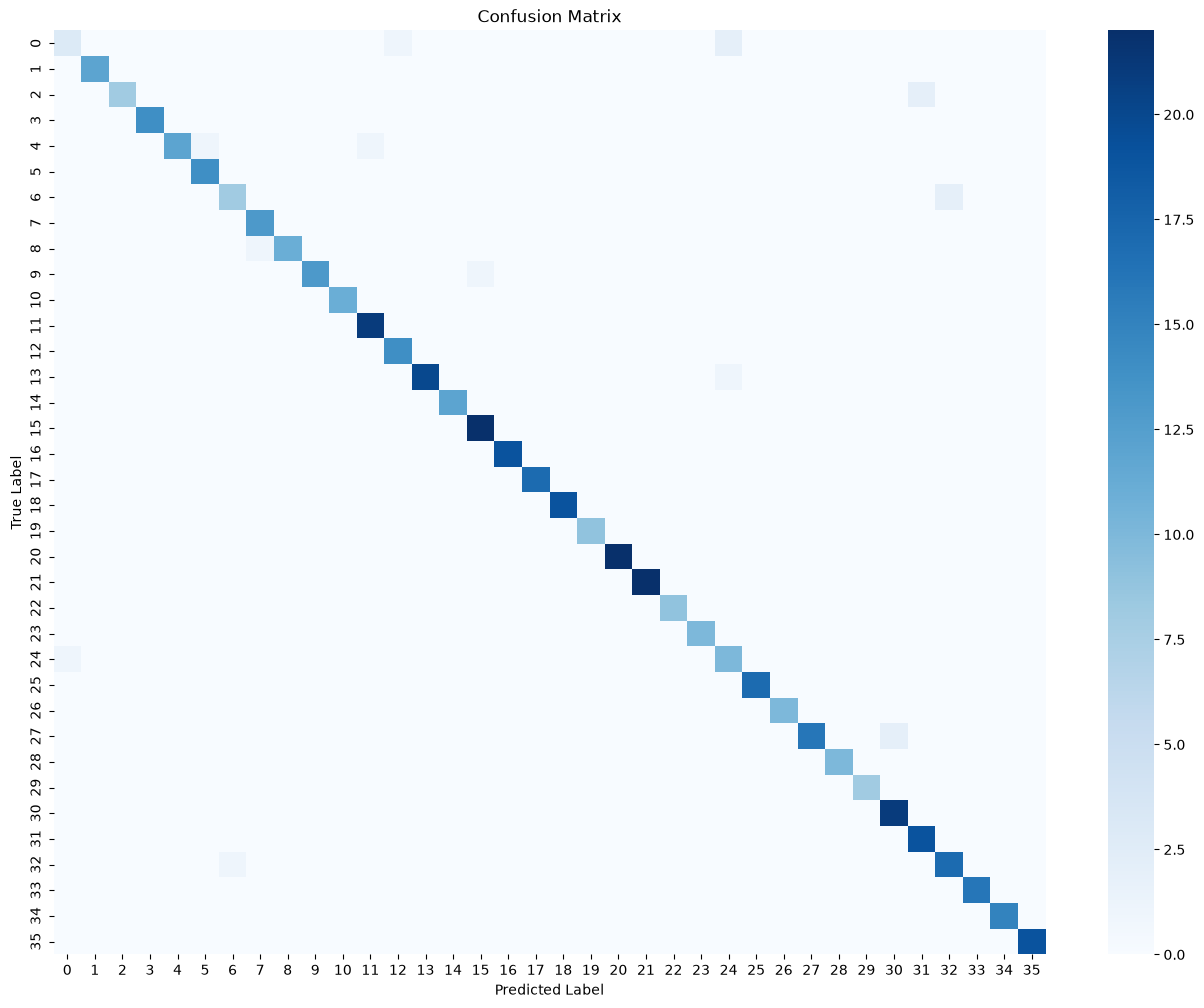

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16,12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [54]:
import joblib

joblib.dump(
    rf,
    "sign_language_model_v2.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [55]:
joblib.dump(
    sorted(y.unique()),
    "label_encoder_v2.pkl"
)

print("Labels Saved")

Labels Saved


In [56]:
print(type(rf))
print(sorted(y.unique())[:5])

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
['0', '1', '2', '3', '4']


In [57]:
import cv2
import joblib
import numpy as np

import mediapipe.python.solutions.hands as mp_hands
import mediapipe.python.solutions.drawing_utils as mp_drawing

model = joblib.load("sign_language_model_v2.pkl")
labels = joblib.load("label_encoder_v2.pkl")

print(type(model))
print("Classes:", len(labels))
print(labels)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Classes: 36
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [58]:
import pyttsx3

def speak(text):
    engine = pyttsx3.init()
    engine.say(text)
    engine.runAndWait()
    engine.stop()

In [59]:
with open("words.txt", "r") as f:
    WORDS = [word.strip().upper() for word in f]

print(len(WORDS))

102


In [60]:
def get_suggestion(text):

    if text.endswith(" "):
        return ""

    if text.strip() == "":
        return ""

    last_word = text.split()[-1].upper()

    if len(last_word) < 3:
        return ""

    for word in WORDS:
        if word.startswith(last_word) and word != last_word:
            return word

    return ""

In [61]:
import cv2
import joblib
import numpy as np

from collections import deque, Counter

import mediapipe.python.solutions.hands as mp_hands
import mediapipe.python.solutions.drawing_utils as mp_drawing

import warnings
warnings.filterwarnings("ignore")

# =========================
# Load Model & Labels
# =========================

model = joblib.load("sign_language_model_v2.pkl")
labels = joblib.load("label_encoder_v2.pkl")

print("Model Loaded Successfully")


# =========================
# MediaPipe Hands
# =========================

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)


# =========================
# Prediction Smoothing
# =========================

predictions = deque(maxlen=20)

#SENTENCE BUILDING
current_word = ""

last_letter = ""
stable_count = 0

ADD_THRESHOLD = 20


# =========================
# Camera
# =========================

cap = cv2.VideoCapture(0)

#=======================
#WINDOW SETTINGS 
#=======================
cv2.namedWindow("Sign Language Recognition", cv2.WINDOW_NORMAL)




#TESTING
current_word = ""

last_letter = ""
stable_count = 0

ADD_THRESHOLD = 20

no_hand_frames = 0
 
while True:

    success, frame = cap.read()

    if not success:
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(rgb)

    if results.multi_hand_landmarks:
        no_hand_frames = 0  #TESTING

        for handedness in results.multi_handedness:
            pass

        for hand_landmarks in results.multi_hand_landmarks:

            # Draw landmarks
            mp_drawing.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

            x_list = []
            y_list = []

            for lm in hand_landmarks.landmark:
                x_list.append(lm.x)
                y_list.append(lm.y)

            min_x = min(x_list)
            min_y = min(y_list)

            max_x = max(x_list)
            max_y = max(y_list)

            width = max_x - min_x
            height = max_y - min_y

            if width > 0 and height > 0:

                features = []

                for lm in hand_landmarks.landmark:

                    if handedness.classification[0].label == "Right":
                        #NORMALIZED LANDMARKS
                        x = 1 - ((lm.x - min_x)/ width)
                    else: 
                        x = (lm.x - min_x)/ width
                    y = (lm.y - min_y)/ height

                    features.append(x)
                    features.append(y)

                features = np.array(features).reshape(1, -1)

                # =========================
                # Prediction
                # =========================

                probs = model.predict_proba(features)[0]

                pred_index = np.argmax(probs)

                prediction = model.classes_[pred_index]

                confidence = probs[pred_index]
                #TESTING
                #===========================
                if prediction == last_letter: 
                    stable_count += 1
                else: 
                    stable_count = 0 
                    last_letter = prediction


                if stable_count == ADD_THRESHOLD:
                    current_word += prediction
                    stable_count = 0

                # =========================
                # Smoothing
                # =========================

                predictions.append(prediction)

                final_prediction = Counter(
                    predictions
                ).most_common(1)[0][0]

                # =========================
                # Display Result
                # =========================

                cv2.putText(
                    frame,
                    f"Letter: {prediction}", #============
                    (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0, 255, 0),
                    2
                )
    else:
        no_hand_frames += 1        
     #===========================
    cv2.putText(
        frame, 
        f"Word: {current_word}",
        (20, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1, 
        (255, 0,0),
        2

     )

    #====================
    #DICTIONARY 
    #=================
    
    suggestion = get_suggestion(current_word)
    cv2.putText(
        frame, 
        f"Suggestion: {suggestion}",
        (20, 150), 
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )

    

    


    cv2.imshow(
        "Sign Language Recognition",
        frame
    )
    #==========================
    key = cv2.waitKey(1) & 0xFF
    #full screen 
    if key == ord('f'):
        cv2.setWindowProperty(
            "Sign Language Recognition",
            cv2.WND_PROP_FULLSCREEN,
            cv2.WINDOW_FULLSCREEN
        )
    #Windowed screen
    if key == ord('w'):
        cv2.setWindowProperty(
            "Sign Language Recognition",
            cv2.WND_PROP_FULLSCREEN,
            cv2.WINDOW_NORMAL
        )

    #clear current word
    if key == ord ('c'):  
        current_word = ""  
    #space bar
    if key == ord(' '):    
        current_word += "   "  
    #backspace
    if key == 8:  
        if len(current_word) > 0: 
            current_word = current_word[:-1]
    #speak current word
    if key == ord ('s'): 
        if current_word.strip() == "":
            speak(" No text available")
        else:
            speak(current_word)
    #Accept suggestion
    if key == 13:
        if suggestion != "":
            words = current_word.split()
            if len(words) > 0:
                words[-1] = suggestion
                current_word = "   ".join(words) + "   "
            
            
    #Escape key
    if key == 27:  
        break


cap.release()
cv2.destroyAllWindows()



Model Loaded Successfully


In [62]:
import os

print(os.path.exists("sign_language_model_v2.pkl"))
print(os.path.exists("label_encoder_v2.pkl"))
print(os.path.exists("hand_landmarks_dataset_v2.csv"))

True
True
True
